In [ ]:
!pip install "numpy<2" qdrant-client deepface tf-keras opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.2/377.2 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 44.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.1 MB/s eta 0:00:00


In [2]:
import os
import tarfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
from deepface import DeepFace

2025-12-27 15:15:07.171882: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766848507.355887      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766848507.409932      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766848507.847244      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766848507.847310      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766848507.847313      55 computation_placer.cc:177] computation placer alr

25-12-27 15:15:20 - Directory /root/.deepface has been created
25-12-27 15:15:20 - Directory /root/.deepface/weights has been created


# --- 1. DÉCOMPRESSION DU DATASET ---

In [ ]:
print("📦 Préparation des données...")

# Chemin du fichier dans ton Input Kaggle
source_tar = "/kaggle/input/lfw-funneled.tgz"
# Dossier de destination (Espace de travail inscriptible de Kaggle)
dest_dir = "/kaggle/working/lfw_dataset"

if not os.path.exists(dest_dir):
    print("⏳ Décompression de l'archive lfw-funneled.tgz (cela peut prendre quelques secondes)...")
    try:
        with tarfile.open(source_tar, "r:gz") as tar:
            tar.extractall(path=dest_dir)
        print("✅ Décompression terminée !")
    except FileNotFoundError:
        print(f"❌ ERREUR : Le fichier {source_tar} est introuvable. Vérifie le chemin dans 'Add Input'.")
else:
    print("✅ Dossier déjà décompressé, on continue.")

# Le dossier racine des images après décompression
root_images = os.path.join(dest_dir, "lfw_funneled")

📦 Préparation des données...
⏳ Décompression de l'archive lfw-funneled.tgz (cela peut prendre quelques secondes)...
✅ Décompression terminée !


# --- 2. INITIALISATION QDRANT ---

In [4]:
client = QdrantClient(":memory:")
collection_name = "base_employes"

client.recreate_collection(
    collection_name=collection_name,
    vectors_config=VectorParams(size=4096, distance=Distance.COSINE),
)

True

# --- 3. INGESTION (Remplissage de la base) ---

In [5]:
print("⚙️ Enrôlement des employés dans la base vectorielle...")

points = []
global_id = 0
limite_employes = 500

# On parcourt les dossiers extraits
# Structure : /lfw_funneled/Nom_Prenom/Nom_Prenom_0001.jpg
for root, dirs, files in os.walk(root_images):
    if global_id >= limite_employes:
        break
    
    # On cherche les images jpg
    jpg_files = [f for f in files if f.endswith('.jpg')]
    
    if jpg_files:
        # On prend la première photo trouvée pour cette personne
        image_name = jpg_files[0]
        image_path = os.path.join(root, image_name)
        
        # Le nom de la personne est le nom du dossier parent
        nom_personne = os.path.basename(root)
        
        try:
            # DeepFace vectorise l'image
            embedding = DeepFace.represent(
                img_path=image_path, 
                model_name="VGG-Face", 
                enforce_detection=False
            )[0]["embedding"]
            
            points.append(PointStruct(
                id=global_id,
                vector=embedding,
                payload={"nom": nom_personne, "path": image_path}
            ))
            
            global_id += 1
            if global_id % 50 == 0:
                print(f"   ... {global_id} employés traités")
                
        except Exception as e:
            continue # Erreur sur une image, on passe

# Envoi vers Qdrant
if points:
    client.upsert(collection_name=collection_name, points=points)
    print(f"✅ Terminé ! {global_id} visages sont stockés dans la base de l'entreprise.")
else:
    print("❌ ERREUR : Aucune image n'a été trouvée. Vérifie les chemins.")

⚙️ Enrôlement des employés dans la base vectorielle...


I0000 00:00:1766848609.409826      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


25-12-27 15:16:49 - 🔗 vgg_face_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5 to /root/.deepface/weights/vgg_face_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /root/.deepface/weights/vgg_face_weights.h5
100%|██████████| 580M/580M [00:04<00:00, 120MB/s]  
I0000 00:00:1766848616.683388      55 cuda_dnn.cc:529] Loaded cuDNN version 91002


   ... 50 employés traités
   ... 100 employés traités
   ... 150 employés traités
   ... 200 employés traités
   ... 250 employés traités
   ... 300 employés traités
   ... 350 employés traités
   ... 400 employés traités
   ... 450 employés traités
   ... 500 employés traités
✅ Terminé ! 500 visages sont stockés dans la base de l'entreprise.


# --- 4. FONCTION DE RECONNAISSANCE ---

In [8]:
def reconnaitre_visage(chemin_photo):
    """
    Prend le chemin d'une photo, l'analyse et cherche la personne dans la base Qdrant.
    """
    print(f"\n🔎 Analyse de l'image...")
    
    # Petit affichage de l'image (Optionnel)
    try:
        img_show = cv2.imread(chemin_photo)
        if img_show is not None:
            img_show = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
            plt.imshow(img_show)
            plt.axis('off')
            plt.show()
    except: pass

    try:
        # 1. Vectorisation
        vec_inconnu = DeepFace.represent(img_path=chemin_photo, model_name="VGG-Face", enforce_detection=True)[0]["embedding"]
        
        # 2. Recherche Qdrant (Avec CORRECTIF pour l'erreur "no attribute search")
        try:
            # On essaie la méthode standard
            result = client.search(
                collection_name="base_employes",
                query_vector=vec_inconnu,
                limit=1
            )
        except AttributeError:
            # PLAN B : Si .search() n'existe pas, on utilise .query_points()
            # C'est la méthode bas niveau qui marche toujours
            result = client.query_points(
                collection_name="base_employes",
                query=vec_inconnu,
                limit=1
            ).points
        
        # 3. Résultat
        if result:
            trouve = result[0]
            # Attention : selon la méthode utilisée, 'payload' est parfois un objet ou un dict
            # On gère les deux cas
            payload = trouve.payload
            nom = payload['nom'] if isinstance(payload, dict) else payload.nom
            
            score = trouve.score 
            seuil_minimum = 0.50 
            
            if score > seuil_minimum:
                print(f"✅ IDENTIFIÉ : C'est {nom}")
                print(f"📊 Confiance : {score:.4f}")
            else:
                print(f"⚠️ VISAGE INCONNU (Ressemble vaguement à {nom}, Score: {score:.4f})")
        else:
            print("❌ Aucune correspondance trouvée.")
            
    except ValueError:
        print("❌ ERREUR : Aucun visage détecté sur cette photo.")
    except Exception as e:
        print(f"❌ ERREUR TECHNIQUE : {str(e)}")

# --- 7. TESTS : photo présente ---


--- TEST 1 : Employé Connu ---
(On teste avec la photo de : Rohinton_Mistry)

🔎 Analyse de l'image...


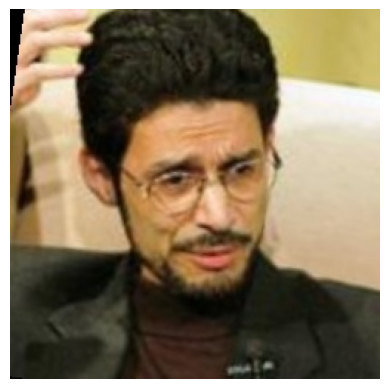

✅ IDENTIFIÉ : C'est Rohinton_Mistry
📊 Confiance : 1.0000


In [10]:
print("\n--- TEST 1 : Employé Connu ---")
# On récupère le chemin d'un employé qu'on a mis dans la base (le dernier ajouté)
if points:
    dernier_employe = points[-1].payload
    print(f"(On teste avec la photo de : {dernier_employe['nom']})")
    reconnaitre_visage(dernier_employe['path'])

# --- 8. TESTS : photo absente ---


--- TEST 2 : Intrus (Michael Jordan) ---
⏳ Téléchargement de la photo de l'intrus...
✅ Photo téléchargée avec succès !

🔎 Analyse de l'image...


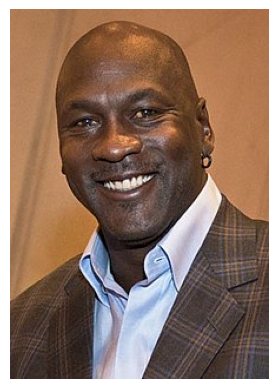

⚠️ VISAGE INCONNU (Ressemble vaguement à Claudio_Abbado, Score: 0.4442)


In [ ]:
# --- TEST 2 : Intrus (Barack Obama via GitHub) ---
import requests

print("\n--- TEST 2 : Intrus (BaMrack Obama) ---")

# ON CHANGE LA SOURCE : On utilise GitHub (Raw) qui ne bloque jamais
url_inconnu = "https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/obama.jpg"
chemin_intrus = "/kaggle/working/intrus.jpg"

try:
    print(f"⏳ Téléchargement depuis GitHub (Source fiable)...")
    
    # Pas besoin de User-Agent compliqué pour GitHub
    reponse = requests.get(url_inconnu, timeout=10)
    
    if reponse.status_code == 200:
        with open(chemin_intrus, 'wb') as f:
            f.write(reponse.content)
        print("✅ Photo téléchargée avec succès !")
        
        # Lancement de la reconnaissance
        reconnaitre_visage(chemin_intrus)
    else:
        print(f"❌ Erreur de téléchargement (Code: {reponse.status_code})")
        
except Exception as e:
    print(f"❌ Erreur technique : {e}")